# Dosis en el hamster

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

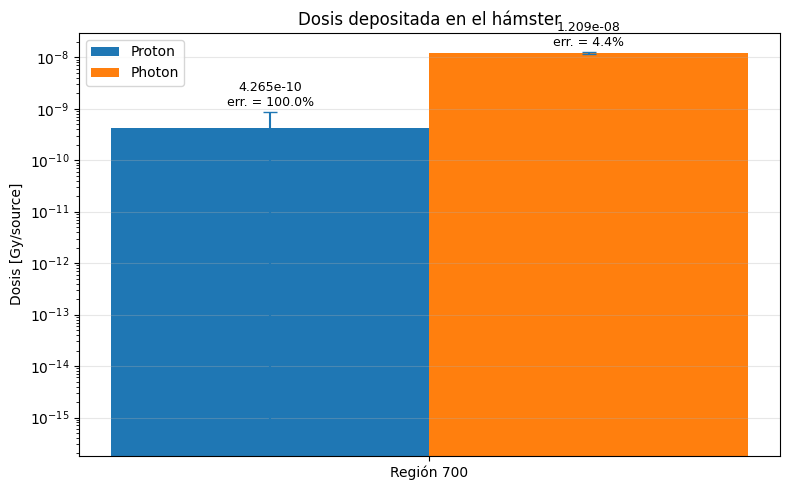

In [3]:
def leer_tdeposit_reg(filename):
    lineas = Path(filename).read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    encabezado = None
    inicio = None

    for i, linea in enumerate(lineas):
        columnas = linea.strip().lstrip("#").split()

        if len(columnas) >= 5 and columnas[:3] == ["num", "reg", "volume"]:
            encabezado = columnas
            inicio = i + 1
            break

    if encabezado is None:
        raise ValueError("No se encontró la tabla de datos del T-Deposit.")

    particulas = encabezado[3::2]

    regiones = []
    volumenes = []
    dosis = []
    errores = []

    for linea in lineas[inicio:]:
        if "sum over" in linea.lower():
            break

        if not linea.strip() or linea.lstrip().startswith("#"):
            continue

        valores = linea.split()

        try:
            numeros = [
                float(valor.replace("D", "E").replace("d", "e"))
                for valor in valores
            ]
        except ValueError:
            continue

        if len(numeros) < 3 + 2 * len(particulas):
            continue

        regiones.append(str(int(numeros[1])))
        volumenes.append(numeros[2])
        dosis.append(numeros[3::2])
        errores.append(numeros[4::2])

    if not dosis:
        raise ValueError("No se encontraron datos numéricos.")

    return (
        regiones,
        particulas,
        np.array(dosis),
        np.array(errores),
        np.array(volumenes)
    )


def graficar_dosis_particulas(filename, escala_log=True, figsize=(8, 5)):
    regiones, particulas, dosis, errores, volumenes = leer_tdeposit_reg(filename)

    x = np.arange(len(regiones))
    ancho = 0.8 / len(particulas)

    fig, ax = plt.subplots(figsize=figsize)

    for j, particula in enumerate(particulas):
        posiciones = x + (j - (len(particulas) - 1) / 2) * ancho
        valores = dosis[:, j]
        errores_absolutos = valores * errores[:, j]
        errores_inferiores = np.minimum(
            errores_absolutos,
            valores * 0.999999
        )

        barras = ax.bar(
            posiciones,
            valores,
            width=ancho,
            label=particula.capitalize()
        )

        ax.errorbar(
            posiciones,
            valores,
            yerr=np.vstack([
                errores_inferiores,
                errores_absolutos
            ]),
            fmt="none",
            capsize=5
        )

        for barra, valor, error in zip(barras, valores, errores[:, j]):
            if valor > 0:
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    valor * (1 + error) * 1.15,
                    f"{valor:.3e}\nerr. = {error * 100:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f"Región {region}" for region in regiones])
    ax.set_ylabel("Dosis [Gy/source]")
    ax.set_title("Dosis depositada en el hámster")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    if escala_log:
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

    return regiones, particulas, dosis, errores, volumenes


archivo = "dosis_hamster_A.out"

regiones, particulas, dosis, errores, volumenes = graficar_dosis_particulas(
    archivo
)

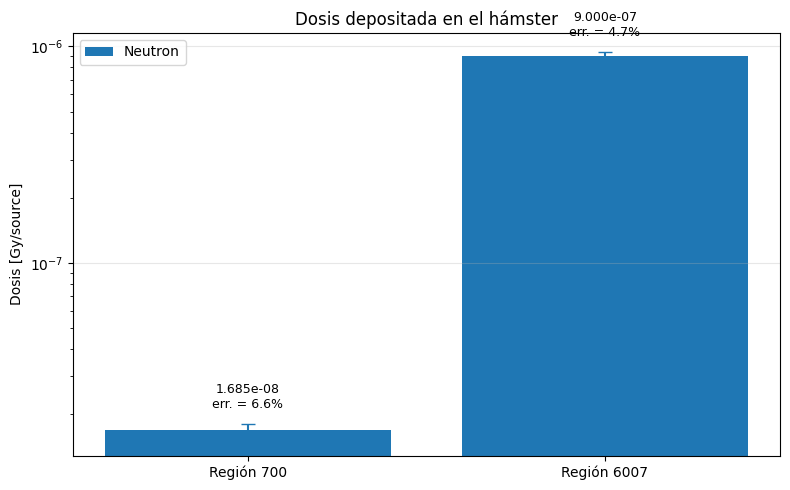

In [4]:
archivo = "dosis_neutron_hamster_A.out"

regiones, particulas, dosis, errores, volumenes = graficar_dosis_particulas(archivo)